In [37]:
import os
import random
import pandas as pd
import numpy as np
import tensorflow as tf
from PIL import Image

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


In [38]:
CLASS_NAMES = [
    "Black Sea Sprat",      # 0
    "Gilt-Head Bream",      # 1
    "Hourse Mackerel",      # 2
    "Red Mullet",           # 3
    "Red Sea Bream",        # 4
    "Sea Bass",             # 5
    "Shrimp",               # 6
    "Striped Red Mullet",   # 7
    "Trout",                # 8
]
print(CLASS_NAMES)

# set to the folder that directly contains the 9 label folders.
src_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset'
# set to a NEW output folder where the notebook will copy images,
# removing any subfolders whose name ends with "GT".
clean_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
# After cleaning, clean_dir should look like:
# <clean_dir>/<Label_i>/<image_files...>

SEED = 42
random.seed(SEED)

['Black Sea Sprat', 'Gilt-Head Bream', 'Hourse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']


In [39]:
selected_rows = []

for cls in CLASS_NAMES:
    class_dir = os.path.join(src_dir, cls)
    if not os.path.isdir(class_dir):
        raise FileNotFoundError(f"Missing class folder: {class_dir}")

    # The dataset has an extra nested folder level; we collect from the subfolder(s) that match the class
    # and skip anything ending with GT.
    candidate_img_paths = []
    for subfolder in os.listdir(class_dir):
        sub_path = os.path.join(class_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue
        if subfolder.endswith("GT"):
            continue
        if subfolder != cls:
            continue

        for fname in os.listdir(sub_path):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                candidate_img_paths.append(os.path.join(sub_path, fname))

    if len(candidate_img_paths) < 3:
        raise ValueError(f"Not enough images for class '{cls}'. Found {len(candidate_img_paths)}")

    chosen = random.sample(candidate_img_paths, 3)
    for p in chosen:
        selected_rows.append({"img_path": p, "true_label_name": cls})

mini_eval_df = pd.DataFrame(selected_rows)
print("Mini eval size:", len(mini_eval_df))
mini_eval_df.head()

Mini eval size: 27


,img_path,true_label_name
0,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat
1,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat
2,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat
3,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream
4,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream


In [40]:
model2 = tf.keras.models.load_model("Models/MobileNetV3Large_Improved.keras")
# Build mapping index -> label name (based on output order)
# IMPORTANT: this assumes the model output index ordering matches CLASS_NAMES order.
idx_to_name = {i: name for i, name in enumerate(CLASS_NAMES)}

def load_and_preprocess_image(path, target_size=(224, 224)):
    img = Image.open(path).convert("RGB").resize(target_size)
    arr = np.array(img).astype("float32")
    #arr = preprocess_input(arr)  # MobileNetV2 specific
    return arr

# Predict
pred_records = []

for i, row in mini_eval_df.iterrows():
    x = load_and_preprocess_image(row["img_path"])
    x = np.expand_dims(x, axis=0)  # batch dimension

    probs = model2.predict(x, verbose=0)[0]  # shape: (num_classes,)
    pred_idx = int(np.argmax(probs))
    pred_name = idx_to_name[pred_idx]
    true_name = row["true_label_name"]

    pred_records.append({
        "img_path": row["img_path"],
        "true_label_name": true_name,
        "pred_label_name": pred_name,
        "pred_prob": float(probs[pred_idx]),
        "pred_idx": pred_idx
    })

pred_df = pd.DataFrame(pred_records)

pred_df.sort_values("true_label_name").reset_index(drop=True).head(30)

,img_path,true_label_name,pred_label_name,pred_prob,pred_idx
0,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat,Black Sea Sprat,1.000000,0
1,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat,Black Sea Sprat,1.000000,0
2,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat,Black Sea Sprat,1.000000,0
3,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream,Gilt-Head Bream,1.000000,1
4,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream,Gilt-Head Bream,1.000000,1
5,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream,Gilt-Head Bream,1.000000,1
6,/home/groggy/data/a-large-scale-fish-dataset/2...,Hourse Mackerel,Hourse Mackerel,1.000000,2
7,/home/groggy/data/a-large-scale-fish-dataset/2...,Hourse Mackerel,Hourse Mackerel,1.000000,2
8,/home/groggy/data/a-large-scale-fish-dataset/2...,Hourse Mackerel,Hourse Mackerel,1.000000,2
9,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,Red Mullet,1.000000,3


In [41]:
model2.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 4,873,373 (18.59 MB)

 Trainable params: 625,673 (2.39 MB)

 Non-trainable params: 2,996,352 (11.43 MB)

 Optimizer params: 1,251,348 (4.77 MB)

In [46]:
conv_candidates = []
for layer in model2.layers:
    # direct layers only (we'll also look deeper if needed)
    try:
        if len(layer.output_shape) == 4:
            conv_candidates.append(layer)
    except Exception:
        pass

print("Top-level 4D layers:", [l.name for l in conv_candidates])

# More robust: find the last conv-like layer anywhere in the model graph
target_layer = None
for layer in reversed(model2.layers):
    # Try to identify actual conv layers by dimensionality + type name
    if "conv" in layer.name.lower():
        try:
            if len(layer.output_shape) == 4:
                target_layer = layer.name
                break
        except Exception:
            continue

# Fallback: last 4D layer if conv name search fails
if target_layer is None:
    for layer in reversed(model2.layers):
        try:
            if len(layer.output_shape) == 4:
                target_layer = layer.name
                break
        except Exception:
            continue

print("Selected Grad-CAM target layer:", target_layer)

Top-level 4D layers: []
Selected Grad-CAM target layer: None


In [47]:
# The model is a flat architecture (not nested), so we work directly with model2.layers
print(f"Total layers in model: {len(model2.layers)}")
print(f"\nFirst 10 layers:")
for i, layer in enumerate(model2.layers[:10]):
    try:
        output_shape = str(layer.output_shape)
    except:
        output_shape = str(layer.output.shape) if hasattr(layer, 'output') else 'N/A'
    print(f"  {i}: {layer.name:50s} {output_shape:30s} {layer.__class__.__name__}")

print(f"\nLast 10 layers:")
for i, layer in enumerate(model2.layers[-10:], start=len(model2.layers)-10):
    try:
        output_shape = str(layer.output_shape)
    except:
        output_shape = str(layer.output.shape) if hasattr(layer, 'output') else 'N/A'
    print(f"  {i}: {layer.name:50s} {output_shape:30s} {layer.__class__.__name__}")

Total layers in model: 193

First 10 layers:
  0: input_layer                                        (None, 224, 224, 3)            InputLayer
  1: rescaling                                          (None, 224, 224, 3)            Rescaling
  2: conv                                               (None, 112, 112, 16)           Conv2D
  3: conv_bn                                            (None, 112, 112, 16)           BatchNormalization
  4: activation                                         (None, 112, 112, 16)           Activation
  5: expanded_conv_depthwise                            (None, 112, 112, 16)           DepthwiseConv2D
  6: expanded_conv_depthwise_bn                         (None, 112, 112, 16)           BatchNormalization
  7: re_lu                                              (None, 112, 112, 16)           ReLU
  8: expanded_conv_project                              (None, 112, 112, 16)           Conv2D
  9: expanded_conv_project_bn                           (None, 112,

In [50]:
# Find all Conv2D layers in the model
conv_layers = []
for layer in model2.layers:
    if 'Conv2D' in layer.__class__.__name__:
        try:
            output_shape = str(layer.output_shape)
        except:
            output_shape = str(layer.output.shape) if hasattr(layer, 'output') else 'N/A'
        conv_layers.append((layer.name, output_shape))

print(f"Found {len(conv_layers)} Conv2D layers")
print(f"\nLast 10 Conv2D layers:")
for name, shape in conv_layers[-10:]:
    print(f"  {name:50s} {shape}")

Found 62 Conv2D layers

Last 10 Conv2D layers:
  expanded_conv_13_depthwise                         (None, 7, 7, 960)
  expanded_conv_13_squeeze_excite_conv               (None, 1, 1, 240)
  expanded_conv_13_squeeze_excite_conv_1             (None, 1, 1, 960)
  expanded_conv_13_project                           (None, 7, 7, 160)
  expanded_conv_14_expand                            (None, 7, 7, 960)
  expanded_conv_14_depthwise                         (None, 7, 7, 960)
  expanded_conv_14_squeeze_excite_conv               (None, 1, 1, 240)
  expanded_conv_14_squeeze_excite_conv_1             (None, 1, 1, 960)
  expanded_conv_14_project                           (None, 7, 7, 160)
  conv_1                                             (None, 7, 7, 960)


In [51]:
# For Grad-CAM, we need the last convolutional layer BEFORE the global pooling/dense layers
# Let's check the last few Conv2D layers more carefully

print("Checking last Conv2D layers:")
conv_count = 0
for layer in reversed(model2.layers):
    if 'Conv2D' in layer.__class__.__name__:
        try:
            shape = layer.output_shape
            print(f"  {layer.name:50s} shape={shape}, len={len(shape) if shape else 'None'}")
            conv_count += 1
            if conv_count >= 5:
                break
        except Exception as e:
            print(f"  {layer.name:50s} ERROR: {e}")

print("\n" + "="*70)
# The last Conv2D layer should be 'conv_1' based on cell #8 output
# This is the final 1x1 conv in MobileNetV3 before global pooling
last_conv_layer = 'conv_1'
print(f"Selected layer for Grad-CAM: {last_conv_layer}")
print(f"Output shape: (None, 7, 7, 960)")

Checking last Conv2D layers:
  conv_1                                             ERROR: 'Conv2D' object has no attribute 'output_shape'
  expanded_conv_14_project                           ERROR: 'Conv2D' object has no attribute 'output_shape'
  expanded_conv_14_squeeze_excite_conv_1             ERROR: 'Conv2D' object has no attribute 'output_shape'
  expanded_conv_14_squeeze_excite_conv               ERROR: 'Conv2D' object has no attribute 'output_shape'
  expanded_conv_14_depthwise                         ERROR: 'DepthwiseConv2D' object has no attribute 'output_shape'
  expanded_conv_14_expand                            ERROR: 'Conv2D' object has no attribute 'output_shape'
  expanded_conv_13_project                           ERROR: 'Conv2D' object has no attribute 'output_shape'
  expanded_conv_13_squeeze_excite_conv_1             ERROR: 'Conv2D' object has no attribute 'output_shape'
  expanded_conv_13_squeeze_excite_conv               ERROR: 'Conv2D' object has no attribute 'outp

In [ ]:
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for a given image.
    
    Args:
        img_array: Preprocessed image array (1, 224, 224, 3)
        model: The full model
        last_conv_layer_name: Name of the last convolutional layer
        pred_index: Class index to visualize (if None, uses the top prediction)
    
    Returns:
        heatmap: Grad-CAM heatmap as numpy array
    """
    # Create a model that maps input -> last conv layer output + predictions
    grad_model = tf.keras.models.Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    # Compute gradient of predicted class w.r.t. last conv layer
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    # Gradient of the class score w.r.t. feature map
    grads = tape.gradient(class_channel, conv_outputs)
    
    # Global average pooling of gradients (importance weights)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Weight feature maps by importance
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize heatmap between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def overlay_heatmap_on_image(img_path, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlay the heatmap on the original image.
    
    Args:
        img_path: Path to original image
        heatmap: Grad-CAM heatmap
        alpha: Transparency of heatmap overlay
        colormap: OpenCV colormap to use
    
    Returns:
        superimposed_img: Image with heatmap overlay
    """
    # Load original image
    img = Image.open(img_path).convert("RGB")
    img = img.resize((224, 224))
    img = np.array(img)
    
    # Rescale heatmap to 0-255 and resize to image size
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (224, 224))
    
    # Apply colormap
    heatmap_colored = cv2.applyColorMap(heatmap, colormap)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Superimpose heatmap on image
    superimposed_img = heatmap_colored * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    
    return img, heatmap_colored, superimposed_img

print("Grad-CAM functions defined!")

Testing Grad-CAM on: /home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Black Sea Sprat/Black Sea Sprat/00550.png
True label: Black Sea Sprat
Predicted: Black Sea Sprat (1.0000)
Image array shape: (1, 224, 224, 3)
Using conv layer: conv_1
Heatmap shape: (7, 7)
Heatmap min: 0.0000, max: 1.0000


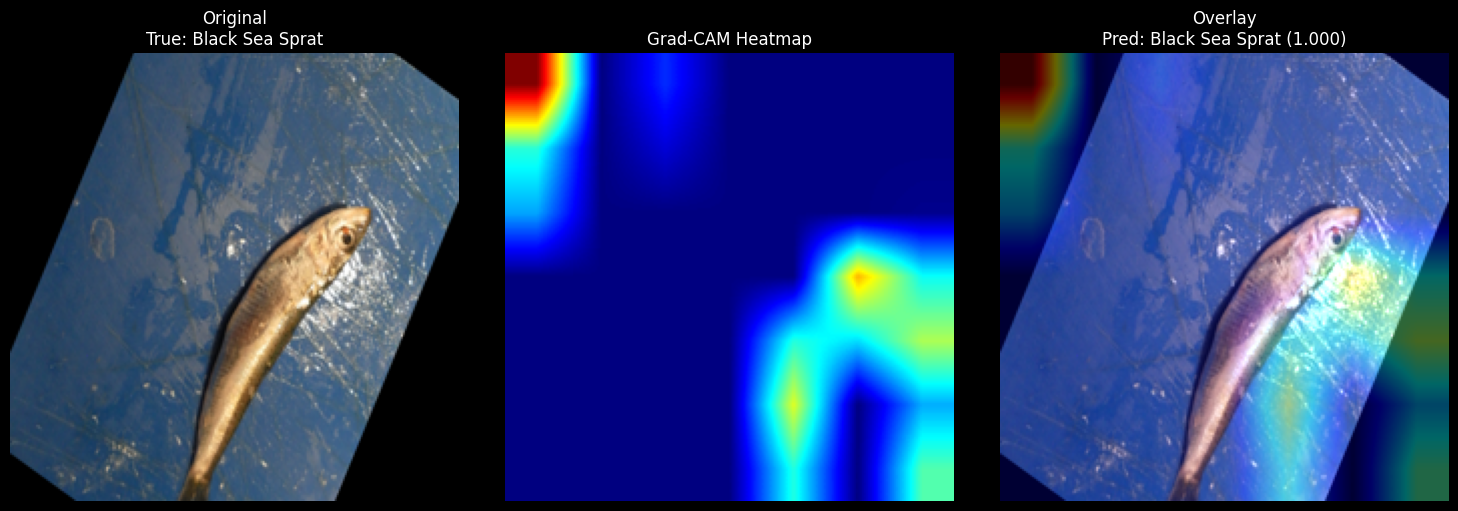

✓ Grad-CAM visualization complete!


In [55]:
# Test on a single image first
test_row = pred_df.iloc[0]
img_path = test_row['img_path']

print(f"Testing Grad-CAM on: {img_path}")
print(f"True label: {test_row['true_label_name']}")
print(f"Predicted: {test_row['pred_label_name']} ({test_row['pred_prob']:.4f})")

# Load and preprocess image
img_array = load_and_preprocess_image(img_path)
img_array = np.expand_dims(img_array, axis=0)

print(f"Image array shape: {img_array.shape}")
print(f"Using conv layer: {last_conv_layer}")

# Generate Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_array, model2, last_conv_layer)
print(f"Heatmap shape: {heatmap.shape}")
print(f"Heatmap min: {heatmap.min():.4f}, max: {heatmap.max():.4f}")

# Overlay on image
original, heatmap_colored, superimposed = overlay_heatmap_on_image(img_path, heatmap)

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original)
axes[0].set_title(f'Original\nTrue: {test_row["true_label_name"]}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(heatmap_colored)
axes[1].set_title('Grad-CAM Heatmap', fontsize=12)
axes[1].axis('off')

axes[2].imshow(superimposed)
axes[2].set_title(f'Overlay\nPred: {test_row["pred_label_name"]} ({test_row["pred_prob"]:.3f})', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Grad-CAM visualization complete!")



Testing Grad-CAM on: /home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Hourse Mackerel/Hourse Mackerel/00747.png
True label: Hourse Mackerel
Predicted: Hourse Mackerel (1.0000)
Image array shape: (1, 224, 224, 3)
Using conv layer: conv_1
Heatmap shape: (7, 7)
Heatmap min: 0.0000, max: 1.0000


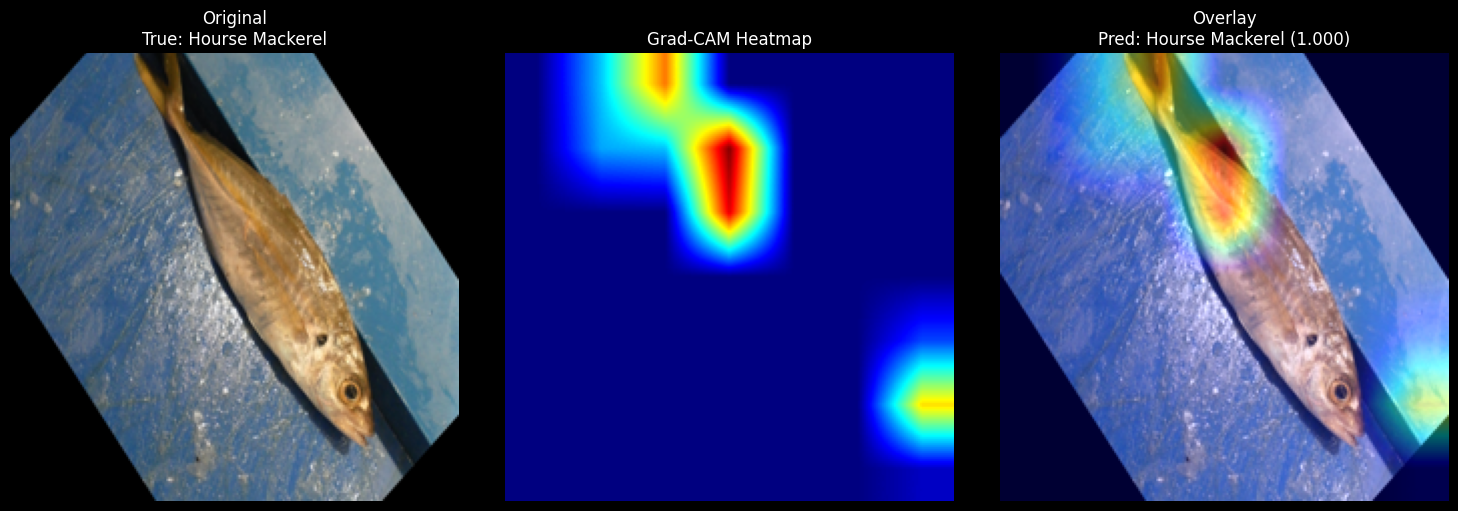

✓ Grad-CAM visualization complete!


In [57]:
# Test on a single image first
test_row = pred_df.iloc[8]
img_path = test_row['img_path']

print(f"Testing Grad-CAM on: {img_path}")
print(f"True label: {test_row['true_label_name']}")
print(f"Predicted: {test_row['pred_label_name']} ({test_row['pred_prob']:.4f})")

# Load and preprocess image
img_array = load_and_preprocess_image(img_path)
img_array = np.expand_dims(img_array, axis=0)

print(f"Image array shape: {img_array.shape}")
print(f"Using conv layer: {last_conv_layer}")

# Generate Grad-CAM heatmap
heatmap = make_gradcam_heatmap(img_array, model2, last_conv_layer)
print(f"Heatmap shape: {heatmap.shape}")
print(f"Heatmap min: {heatmap.min():.4f}, max: {heatmap.max():.4f}")

# Overlay on image
original, heatmap_colored, superimposed = overlay_heatmap_on_image(img_path, heatmap)

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original)
axes[0].set_title(f'Original\nTrue: {test_row["true_label_name"]}', fontsize=12)
axes[0].axis('off')

axes[1].imshow(heatmap_colored)
axes[1].set_title('Grad-CAM Heatmap', fontsize=12)
axes[1].axis('off')

axes[2].imshow(superimposed)
axes[2].set_title(f'Overlay\nPred: {test_row["pred_label_name"]} ({test_row["pred_prob"]:.3f})', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Grad-CAM visualization complete!")

